# 3. Exploration — Horaires de badgeage (`in_out_time/`)

Ce notebook explore les fichiers `in_time.csv` et `out_time.csv` qui contiennent
les horodatages d'arrivée et de départ de chaque employé pour chaque jour ouvré de 2015.

L'objectif est de comprendre la structure de ces fichiers et d'en dériver des indicateurs
exploitables (heures moyennes de travail, retards, etc.).

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3.1 Chargement et structure

In [14]:
df_in = pd.read_csv("data/in_out_time/in_time.csv", index_col=0)
df_out = pd.read_csv("data/in_out_time/out_time.csv", index_col=0)

print(f"in_time  : {df_in.shape[0]} employés × {df_in.shape[1]} jours")
print(f"out_time : {df_out.shape[0]} employés × {df_out.shape[1]} jours")
print(f"\nPériode couverte : du {df_in.columns[0]} au {df_in.columns[-1]}")

in_time  : 4410 employés × 261 jours
out_time : 4410 employés × 261 jours

Période couverte : du 2015-01-01 au 2015-12-31


In [15]:
# Aperçu des premières colonnes
df_in.iloc[:5, :5]

,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07
1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31
2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17
3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27
4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30
5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37


In [16]:
df_out.iloc[:5, :5]

,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07
1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55
2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06
3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21
4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40
5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59


## 3.2 Identification de la clé (`index` = EmployeeID)

L'index des fichiers correspond à l'`EmployeeID` utilisé dans les autres datasets.

In [17]:
print(f"Index in_time  — min: {df_in.index.min()}, max: {df_in.index.max()}, "
      f"uniques: {df_in.index.nunique()}")
print(f"Index out_time — min: {df_out.index.min()}, max: {df_out.index.max()}, "
      f"uniques: {df_out.index.nunique()}")
print(f"\nIndex identiques entre in et out : {df_in.index.equals(df_out.index)}")
print(f"Colonnes (dates) identiques       : {df_in.columns.equals(df_out.columns)}")

Index in_time  — min: 1, max: 4410, uniques: 4410
Index out_time — min: 1, max: 4410, uniques: 4410

Index identiques entre in et out : True
Colonnes (dates) identiques       : True


## 3.3 Valeurs manquantes (absences / congés)

In [18]:
# Taux de NA global
na_rate_in = df_in.isnull().sum().sum() / df_in.size * 100
na_rate_out = df_out.isnull().sum().sum() / df_out.size * 100
print(f"Taux de NA — in_time : {na_rate_in:.1f}%")
print(f"Taux de NA — out_time: {na_rate_out:.1f}%")

Taux de NA — in_time : 9.5%
Taux de NA — out_time: 9.5%


Jours d'absence par employé — stats :
count    4410.000000
mean       24.734694
std         5.503779
min        13.000000
25%        20.000000
50%        25.000000
75%        29.000000
max        36.000000
dtype: float64


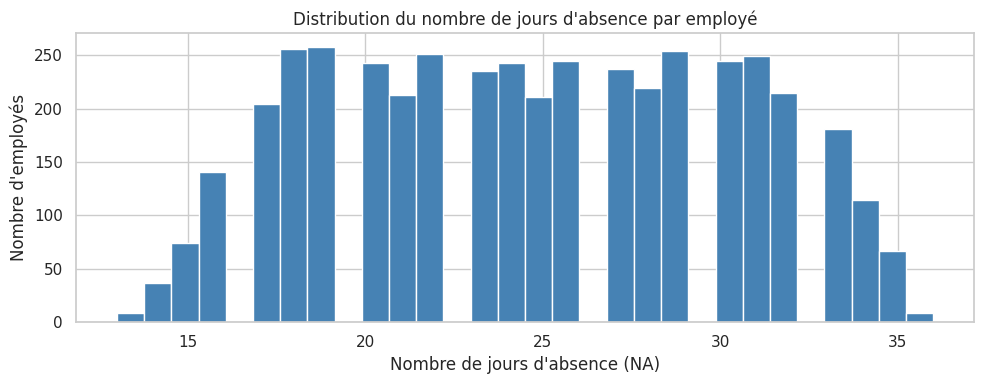

In [19]:
# Nombre de jours d'absence par employé
absences_par_employe = df_in.isnull().sum(axis=1)
print(f"Jours d'absence par employé — stats :")
print(absences_par_employe.describe())

fig, ax = plt.subplots(figsize=(10, 4))
absences_par_employe.hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribution du nombre de jours d'absence par employé")
ax.set_xlabel("Nombre de jours d'absence (NA)")
ax.set_ylabel("Nombre d'employés")
plt.tight_layout()
plt.show()

## 3.4 Calcul du temps de travail quotidien

In [20]:
# Convertir toutes les cellules en datetime
df_in_dt = df_in.apply(pd.to_datetime, errors="coerce")
df_out_dt = df_out.apply(pd.to_datetime, errors="coerce")

# Calculer la durée de travail en heures
df_duration = (df_out_dt - df_in_dt).apply(
    lambda col: col.dt.total_seconds() / 3600
)

print("Durée de travail quotidienne (heures) — aperçu :")
df_duration.iloc[:5, :5]

Durée de travail quotidienne (heures) — aperçu :


,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07
1,NaN,7.208333,7.189722,7.410833,7.006667
2,NaN,8.109167,7.454722,NaN,7.396944
3,NaN,6.692500,7.265556,6.405278,6.765000
4,NaN,7.338333,7.291944,6.943056,6.919444
5,NaN,8.055556,7.988056,7.682500,7.806111


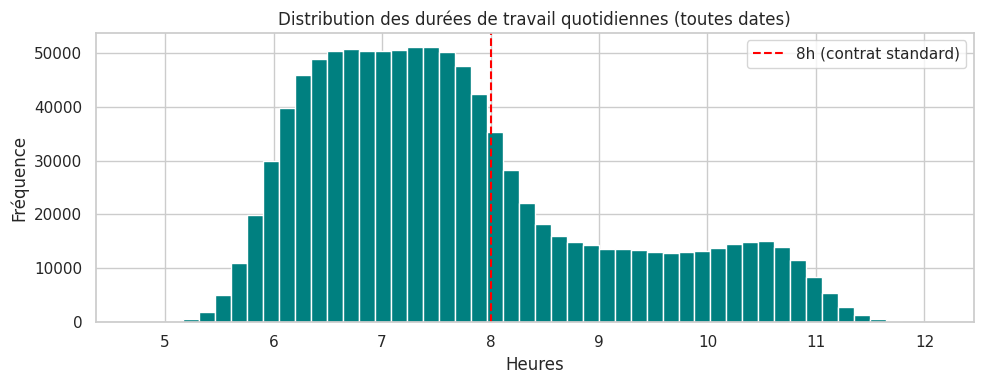

Durée moyenne : 7.71h
Durée médiane : 7.42h


In [21]:
# Distribution globale de la durée de travail quotidienne
all_durations = df_duration.values.flatten()
all_durations = all_durations[~pd.isnull(all_durations)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_durations, bins=50, color="teal", edgecolor="white")
ax.axvline(8, color="red", linestyle="--", label="8h (contrat standard)")
ax.set_title("Distribution des durées de travail quotidiennes (toutes dates)")
ax.set_xlabel("Heures")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Durée moyenne : {all_durations.mean():.2f}h")
print(f"Durée médiane : {pd.Series(all_durations).median():.2f}h")

## 3.5 Indicateurs agrégés par employé

On calcule des features exploitables par employé pour un futur merge.

In [22]:
# Heures d'arrivée moyennes par employé
df_in_hours = df_in_dt.apply(lambda col: col.dt.hour + col.dt.minute / 60)
df_out_hours = df_out_dt.apply(lambda col: col.dt.hour + col.dt.minute / 60)

time_features = pd.DataFrame({
    "EmployeeID": df_in.index,
    "avg_in_hour": df_in_hours.mean(axis=1).values,
    "avg_out_hour": df_out_hours.mean(axis=1).values,
    "avg_work_hours": df_duration.mean(axis=1).values,
    "std_work_hours": df_duration.std(axis=1).values,
    "nb_days_present": df_duration.notna().sum(axis=1).values,
    "nb_days_absent": df_duration.isna().sum(axis=1).values,
})

print(f"Features temporelles : {time_features.shape}")
time_features.head(10)

Features temporelles : (4410, 7)


,EmployeeID,avg_in_hour,avg_out_hour,avg_work_hours,std_work_hours,nb_days_present,nb_days_absent
0,1,9.993032,17.367170,7.373651,0.283224,232,29
1,2,9.980720,17.698446,7.718969,0.313351,236,25
2,3,10.016598,17.030096,7.013240,0.311551,242,19
3,4,9.973830,17.167305,7.193678,0.284133,235,26
4,5,9.990068,17.996327,8.006175,0.300656,245,16
5,6,9.980450,20.776512,10.796096,0.306278,237,24
6,7,9.956250,16.879310,6.923570,0.324612,232,29
7,8,9.994102,16.719616,6.725621,0.278548,243,18
8,9,10.013841,17.250725,7.236499,0.310700,230,31
9,10,9.956838,17.036467,7.080088,0.290491,234,27


In [23]:
time_features.describe()

,EmployeeID,avg_in_hour,avg_out_hour,avg_work_hours,std_work_hours,nb_days_present,nb_days_absent
count,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,2205.500000,9.991773,17.692558,7.700792,0.299578,236.265306,24.734694
std,1273.201673,0.018147,1.340417,1.340218,0.013721,5.503779,5.503779
min,1.000000,9.929079,15.942330,5.950504,0.254754,225.000000,13.000000
25%,1103.250000,9.979616,16.656231,6.673333,0.289964,232.000000,20.000000
50%,2205.500000,9.991957,17.400237,7.406761,0.299544,236.000000,25.000000
75%,3307.750000,10.003581,18.352469,8.368703,0.308990,241.000000,29.000000
max,4410.000000,10.069684,21.058616,11.030960,0.344907,248.000000,36.000000


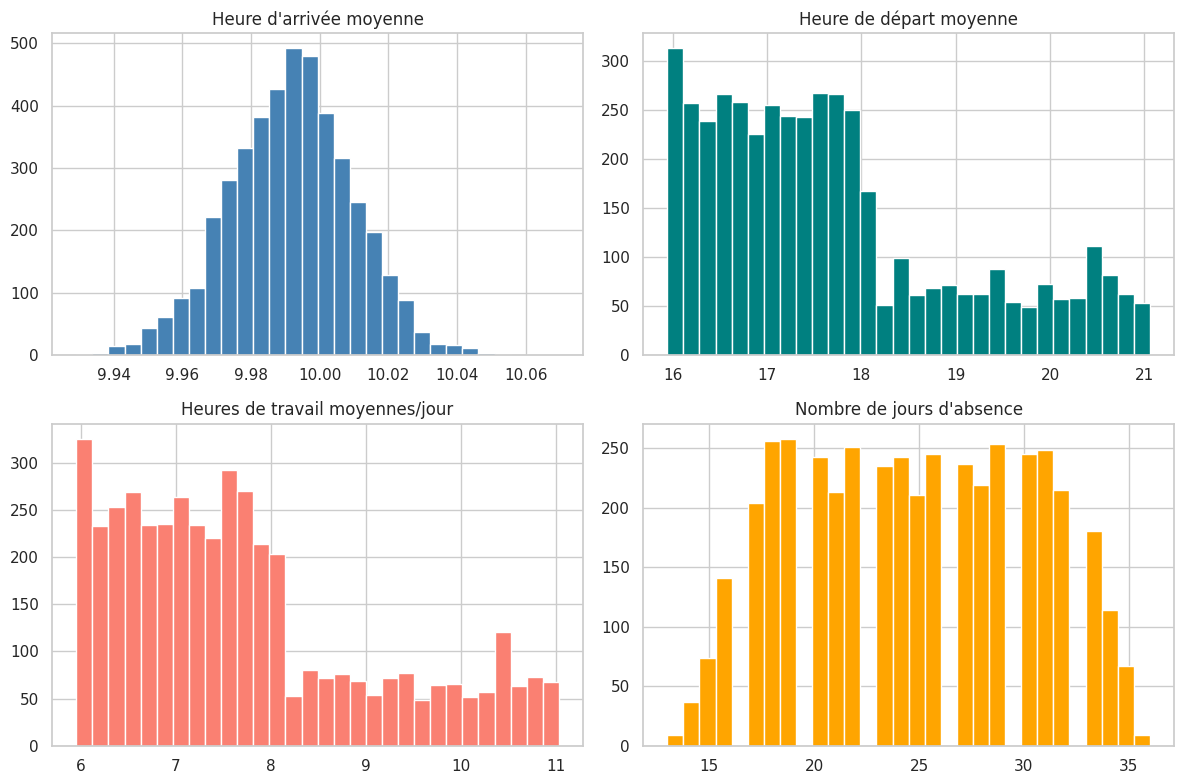

In [24]:
# Visualisation des indicateurs
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

time_features["avg_in_hour"].hist(bins=30, ax=axes[0, 0], color="steelblue", edgecolor="white")
axes[0, 0].set_title("Heure d'arrivée moyenne")

time_features["avg_out_hour"].hist(bins=30, ax=axes[0, 1], color="teal", edgecolor="white")
axes[0, 1].set_title("Heure de départ moyenne")

time_features["avg_work_hours"].hist(bins=30, ax=axes[1, 0], color="salmon", edgecolor="white")
axes[1, 0].set_title("Heures de travail moyennes/jour")

time_features["nb_days_absent"].hist(bins=30, ax=axes[1, 1], color="orange", edgecolor="white")
axes[1, 1].set_title("Nombre de jours d'absence")

plt.tight_layout()
plt.show()